<a href="https://colab.research.google.com/github/reskiyani2006-arch/diamond-price-ml/blob/main/Food_Delivery_Dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prediksi Waktu Pengiriman Pesanan Berdasarkan Jarak Pengiriman, Jenis Kendaraan, dan Kondisi Operasional

IMPORT LIBRARY

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

LOAD DATA

In [ ]:
df = pd.read_csv('/content/train.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


Exploratory Data Analysis (EDA)

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


Data Cleaning (Pembersihan Data)

In [ ]:
df['Time_taken(min)'] = df['Time_taken(min)'].astype(str).str.replace('(min)', '', regex=False)
df['Time_taken(min)'] = df['Time_taken(min)'].str.strip()

df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')

df = df.dropna(subset=['Time_taken(min)'])

In [ ]:
df = df.drop(['ID', 'Delivery_person_ID', 'Order_Date'], axis=1, errors='ignore')

FEATURE ENGINEERING

In [ ]:
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')

df['prep_time'] = (
    df['Time_Order_picked'] - df['Time_Orderd']
).dt.total_seconds() / 60

df['order_hour'] = df['Time_Orderd'].dt.hour
df['pickup_hour'] = df['Time_Order_picked'].dt.hour


/tmp/ipykernel_25867/1342149964.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')
/tmp/ipykernel_25867/1342149964.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')


In [ ]:
df = df.drop(['Time_Orderd','Time_Order_picked'], axis=1)

HANDLE MISSING VALUE

In [ ]:
df = df.replace('NaN', np.nan)
df = df.dropna()

REMOVE OUTLIER (IQR)

In [ ]:
q1 = df['Time_taken(min)'].quantile(0.25)
q3 = df['Time_taken(min)'].quantile(0.75)
iqr = q3 - q1
df = df[(df['Time_taken(min)'] >= q1 - 1.5*iqr) &
        (df['Time_taken(min)'] <= q3 + 1.5*iqr)]

Feature Engineering Tambahan (Distance)

In [ ]:
df['distance'] = np.sqrt(
    (df['Restaurant_latitude'] - df['Delivery_location_latitude'])**2 +
    (df['Restaurant_longitude'] - df['Delivery_location_longitude'])**2
)

Encoding Data

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Visualisasi Distribusi

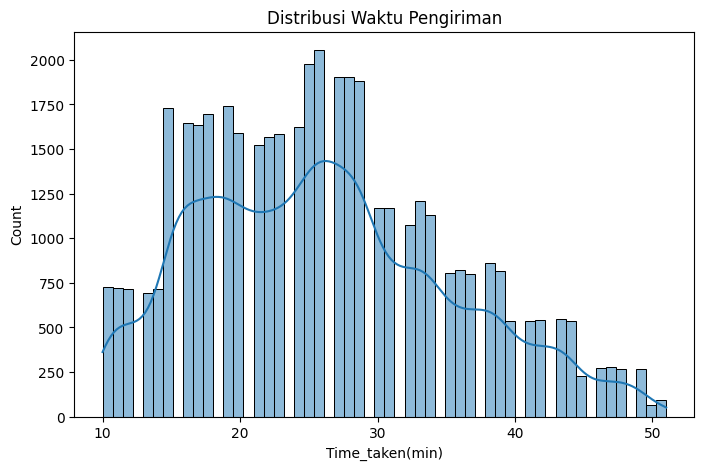

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Time_taken(min)'], kde=True)
plt.title("Distribusi Waktu Pengiriman")
plt.show()

Heatmap Korelasi

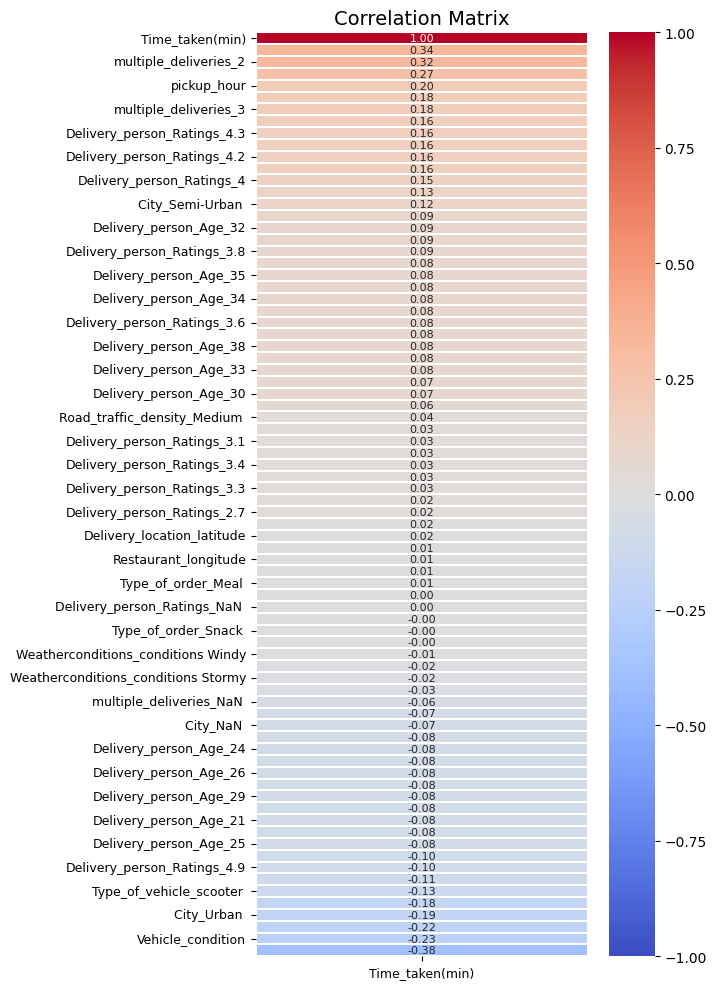

In [ ]:
plt.figure(figsize=(7,10))

corr = df.corr(numeric_only=True)[['Time_taken(min)']]
corr = corr.sort_values(by='Time_taken(min)', ascending=False)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='white',
    cbar=True,
    annot_kws={"size":8}
)

plt.title("Correlation Matrix", fontsize=14)
plt.yticks(rotation=0, fontsize=9)
plt.xticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame and 'Time_taken(min)' is the target variable
# Define features (X) and target (y)
X_full = df.drop('Time_taken(min)', axis=1)
y_full = df['Time_taken(min)']

# Split the data into training and testing sets (using a common split ratio as an example)
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
df['distance_per_time'] = df['distance'] / df['Time_taken(min)']

In [ ]:
from sklearn.model_selection import cross_val_score
from catboost import CatBoostRegressor # Import CatBoostRegressor

# Instantiate the CatBoostRegressor model
cat = CatBoostRegressor(verbose=0, random_state=42)

# Use X_full and y_full for cross-validation, as they represent the full dataset
scores = cross_val_score(cat, X_full, y_full, cv=5, scoring='r2')
print(scores.mean())

0.8067705094912757


Split Data & Evaluasi

In [ ]:
splits = { "70:30": 0.3, "80:20": 0.2, "90:10": 0.1 }
results = []

def evaluate(y_test, y_pred, model_name, split_name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {
        "Split": split_name,
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

# Drop NaN
df_cleaned = df.dropna()
X = df_cleaned.drop('Time_taken(min)', axis=1)
y = df_cleaned['Time_taken(min)']

for name, test_size in splits.items():
    print(f"\n========== SPLIT {name} ==========")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # =========================
    # CatBoost
    # =========================
    cat = CatBoostRegressor(
        iterations=300,
        depth=3,
        learning_rate=0.05,
        l2_leaf_reg=20,
        verbose=0,
        early_stopping_rounds=30
    )
    cat.fit(X_train, y_train, eval_set=(X_test, y_test))
    y_pred_cat = cat.predict(X_test)
    results.append(evaluate(y_test, y_pred_cat, "CatBoost", name))

    # =========================
    # Random Forest
    # =========================
    param_rf = {
        'n_estimators':[100,200],
        'max_depth':[5,10],
        'min_samples_split':[2,5],
        'min_samples_leaf':[3,5]
    }

    grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_rf, cv=3, n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    rf_best = grid_rf.best_estimator_
    y_pred_rf = rf_best.predict(X_test)
    results.append(evaluate(y_test, y_pred_rf, "Random Forest", name))

    # =========================
    # XGBoost
    # =========================
    param_xgb = {
        'n_estimators':[100,150],
        'max_depth':[2,3],
        'learning_rate':[0.05,0.1],
        'subsample':[0.6,0.7],
        'colsample_bytree':[0.6,0.7],
        'reg_alpha':[1,2],
        'reg_lambda':[3,5]
    }
    grid_xgb = GridSearchCV(XGBRegressor(random_state=42, eval_metric='rmse'), param_xgb, cv=3, n_jobs=-1)
    grid_xgb.fit(X_train, y_train)
    xgb_best = grid_xgb.best_estimator_
    y_pred_xgb = xgb_best.predict(X_test)
    results.append(evaluate(y_test, y_pred_xgb, "XGBoost", name))

    # =========================
    # Print hasil
    # =========================
    for res in results[-3:]:
        print(f"\nModel: {res['Model']} | Split: {res['Split']}")
        print("MAE :", res["MAE"])
        print("MSE :", res["MSE"])
        print("RMSE:", res["RMSE"])
        print("R2 :", res["R2 Score"])


========== SPLIT 70:30 ==========

Model: CatBoost | Split: 70:30
MAE : 1.1742219941078182
MSE : 2.5799617256701093
RMSE: 1.6062259260982277
R2 : 0.9693402927422126

Model: Random Forest | Split: 70:30
MAE : 0.4352688911304228
MSE : 1.5321470240273642
RMSE: 1.2377992664512951
R2 : 0.981792296077428

Model: XGBoost | Split: 70:30
MAE : 1.1519312858581543
MSE : 2.5967395305633545
RMSE: 1.6114402038435538
R2 : 0.969140887260437

========== SPLIT 80:20 ==========

Model: CatBoost | Split: 80:20
MAE : 1.1820675477167293
MSE : 2.5974888742973903
RMSE: 1.6116726945311788
R2 : 0.969034810281794

Model: Random Forest | Split: 80:20
MAE : 0.4435062707673739
MSE : 1.5739918699144821
RMSE: 1.2545883268684124
R2 : 0.9812361248784947

Model: XGBoost | Split: 80:20
MAE : 1.1256242990493774
MSE : 2.4549999237060547
RMSE: 1.5668439372528633
R2 : 0.9707334637641907

========== SPLIT 90:10 ==========

Model: CatBoost | Split: 90:10
MAE : 1.1630501098072006
MSE : 2.5080919988609907
RMSE: 1.58369567747752

HASIL AKHIR

In [ ]:
results_df = pd.DataFrame(results, columns=['Split', 'Model', 'MAE', 'RMSE', 'R2 Score'])
results_df = results_df.sort_values(by=['Split','R2 Score'], ascending=[True, False])
print("\n=== Tabel Perbandingan Model ===")
display(results_df)

results_df_unique = results_df.drop_duplicates(subset=['Split', 'Model'])

# Pivot table R²
pivot_r2 = results_df_unique.pivot(index='Split', columns='Model', values='R2 Score')
print("\n=== Pivot Table R² Score ===")
display(pivot_r2)


=== Tabel Perbandingan Model ===


,Split,Model,MAE,RMSE,R2 Score
1,70:30,Random Forest,0.435269,1.237799,0.981792
0,70:30,CatBoost,1.174222,1.606226,0.969340
2,70:30,XGBoost,1.151931,1.611440,0.969141
4,80:20,Random Forest,0.443506,1.254588,0.981236
5,80:20,XGBoost,1.125624,1.566844,0.970733
3,80:20,CatBoost,1.182068,1.611673,0.969035
7,90:10,Random Forest,0.462365,1.325461,0.978882
8,90:10,XGBoost,1.125012,1.574508,0.970201
6,90:10,CatBoost,1.163050,1.583696,0.969852



=== Pivot Table R² Score ===


Model,CatBoost,Random Forest,XGBoost
Split,,,
70:30,0.969340,0.981792,0.969141
80:20,0.969035,0.981236,0.970733
90:10,0.969852,0.978882,0.970201


In [ ]:
# =========================
# MODEL TERBAIK BERDASARKAN R²
# =========================
best_model_row = results_df.loc[results_df['R2 Score'].idxmax()]

print("🔥 MODEL TERBAIK 🔥")
print(f"Split       : {best_model_row['Split']}")
print(f"Model       : {best_model_row['Model']}")
print(f"MAE         : {best_model_row['MAE']:.3f}")
print(f"RMSE        : {best_model_row['RMSE']:.3f}")
print(f"R² Score    : {best_model_row['R2 Score']:.3f}")

🔥 MODEL TERBAIK 🔥
Split       : 70:30
Model       : Random Forest
MAE         : 0.435
RMSE        : 1.238
R² Score    : 0.982
